In [1]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password="***",
    host="localhost",
    port=3306,
    database="encommerce_analysis"
)
engine = create_engine(url)

category_sql = """
SELECT DATE_FORMAT(order_purchase_timestamp,'%%Y-%%m') AS months,
       COALESCE(product_category_name_english,
                products.product_category_name,
                'unknown') AS category,
       SUM(price) AS total_sales,
       COUNT(order_item_id) AS item_count,
       COUNT(DISTINCT orders.order_id) AS order_count
FROM products
JOIN order_items
    ON products.product_id = order_items.product_id
JOIN orders
    ON order_items.order_id = orders.order_id
LEFT JOIN translation
    ON products.product_category_name = translation.product_category_name
WHERE order_status = 'delivered'
GROUP BY months, category
ORDER BY months;
"""

monthly_category = pd.read_sql(category_sql, engine)

In [6]:
# 将category这一列数据中多余的字符去掉（数据清洗）
monthly_category["category"] = monthly_category["category"].str.strip()
# 查看数据各项属性
print(monthly_category.shape)
print(monthly_category.info())
print(monthly_category.isnull().sum())
print(monthly_category.head())
print(monthly_category["category"].nunique())

(1273, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   months       1273 non-null   object 
 1   category     1273 non-null   object 
 2   total_sales  1273 non-null   float64
 3   item_count   1273 non-null   int64  
 4   order_count  1273 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 49.9+ KB
None
months         0
category       0
total_sales    0
item_count     0
order_count    0
dtype: int64
    months          category  total_sales  item_count  order_count
0  2016-09     health_beauty       134.97           3            1
1  2016-10  air_conditioning      1349.29           8            4
2  2016-10             audio       156.99           2            2
3  2016-10              auto      1128.26           8            8
4  2016-10              baby      1371.17          11            9
74


In [9]:
# 将日期列的字符格式化为时间格式
monthly_category["months"] = pd.to_datetime(monthly_category["months"])
# 限定分析数据的时间区间
monthly_category_analysis = monthly_category[
    monthly_category["months"] >= "2017-01-01"].copy()

print(monthly_category_analysis.shape)
print(monthly_category_analysis[
    monthly_category_analysis["category"] == "unknown"])

(1241, 5)
         months category  total_sales  item_count  order_count
73   2017-01-01  unknown      1603.64          12           10
124  2017-02-01  unknown      8521.11          56           50
177  2017-03-01  unknown      6457.17          60           54
235  2017-04-01  unknown      8448.19          69           61
295  2017-05-01  unknown     10818.34          91           82
356  2017-06-01  unknown      4902.40          58           50
418  2017-07-01  unknown      2967.86          58           52
481  2017-08-01  unknown      4968.45          75           64
547  2017-09-01  unknown      5774.15          73           61
611  2017-10-01  unknown     16321.27          68           58
677  2017-11-01  unknown     13786.55         118          111
740  2017-12-01  unknown     15497.67         137          132
807  2018-01-01  unknown     20993.63         193          171
872  2018-02-01  unknown     12691.97         117          107
939  2018-03-01  unknown     16625.22        

In [12]:
# 计算总销量以及种类为unknown的销量
total_sales_all = monthly_category_analysis["total_sales"].sum()
unknown_sales = monthly_category_analysis[
    monthly_category_analysis["category"] == "unknown"
]["total_sales"].sum()
print(total_sales_all)
print(unknown_sales)
# 计算unknown销量的占比
unknown_sales_rate = unknown_sales / total_sales_all * 100
print("unknown销售额占比：", unknown_sales_rate)

# 将非unknown的数据提取出来，用作后续数据分析
category_analysis = monthly_category_analysis[
    monthly_category_analysis["category"] != "unknown"].copy()
print(category_analysis.shape)
print(category_analysis["category"].nunique())

13181027.129999999
170660.74
unknown销售额占比： 1.294745381500478
(1221, 5)
73


In [16]:
# 将表格按商品品类分类，并求和总销量、商品数、订单数，整合成一列表格
category_summary = (category_analysis.groupby("category")
    .agg({"total_sales": "sum","item_count": "sum","order_count": "sum"}).reset_index())
# 将整合的数据按总销量排序（降序）
category_summary = category_summary.sort_values(by="total_sales",ascending=False)
# 计算各类商品销售额的占比
category_summary["sales_share"] = (category_summary["total_sales"]
    / category_summary["total_sales"].sum()* 100)
print(category_summary.head(10))
# 前十销售额的总贡献率
top10_share = category_summary.head(10)["sales_share"].sum()
print("Top10品类销售额占比：", top10_share)

#正式开始画图，先将销售额前十商品品类进行升序排列
import matplotlib.pyplot as plt
top10_category = category_summary.head(10).sort_values(
    by="total_sales",ascending=True)
# 画横向柱状图
plt.figure(figsize=(10, 6))
plt.barh(
    top10_category["category"],top10_category["total_sales"])
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.title("Top 10 Categories by Total Sales")
plt.tight_layout()
plt.show()

                 category  total_sales  item_count  order_count  sales_share
43          health_beauty   1229557.50        9422         8610     9.450599
72          watches_gifts   1163465.91        5855         5491     8.942607
7          bed_bath_table   1022955.77       10945         9267     7.862621
67         sports_leisure    952840.40        8414         7513     7.323702
15  computers_accessories    888055.59        7632         6518     6.825754
39        furniture_decor    706237.17        8095         6258     5.428265
49             housewares    614341.62        6783         5734     4.721939
20             cool_stuff    609158.00        3711         3552     4.682097
5                    auto    577838.39        4132         3802     4.441369
42           garden_tools    469135.40        4263         3443     3.605858
Top10品类销售额占比： 63.28481076696258


In [18]:
# 单独提取2017年11月的数据，查找该月销售额高的具体原因
nov_2017 = category_analysis[category_analysis["months"] == "2017-11-01"].copy()
# 按销售额降序排列品类，并查看前十的商品
nov_2017 = nov_2017.sort_values(by="total_sales",ascending=False)
print(nov_2017.head(10))

        months               category  total_sales  item_count  order_count
678 2017-11-01          watches_gifts     95292.34         463          424
619 2017-11-01         bed_bath_table     87957.63         961          804
653 2017-11-01          health_beauty     78274.40         573          519
627 2017-11-01  computers_accessories     69676.32         512          431
672 2017-11-01         sports_leisure     62686.24         597          542
676 2017-11-01                   toys     62611.26         485          443
649 2017-11-01        furniture_decor     62091.27         767          536
632 2017-11-01             cool_stuff     55696.66         297          286
652 2017-11-01           garden_tools     44275.18         547          430
617 2017-11-01                   auto     34736.49         260          242


In [20]:
# 建立正常月份基准，计算平时月均销售额（长期基准比较）
# 先将2017-11本身排除
normal_months = category_analysis[category_analysis["months"] != "2017-11-01"].copy()
# 再计算每个品类的月均销售额，并整理成表格
category_avg = (normal_months.groupby("category")["total_sales"].mean().reset_index())
category_avg = category_avg.rename(columns={"total_sales": "avg_monthly_sales"})
print(category_avg.head())
# 将11月的数据与月均数据关联上
nov_compare = nov_2017.merge(category_avg,on="category",how="left")
# 计算11月数据相对月均数据的绝对增量和相对增幅
nov_compare["sales_increase"] = (
    nov_compare["total_sales"]- nov_compare["avg_monthly_sales"])
nov_compare["growth_rate"] = (
    nov_compare["sales_increase"] /nov_compare["avg_monthly_sales"]* 100)
# 将数据按绝对增量的降序排列，并查看前十的商品
nov_compare = nov_compare.sort_values(by="sales_increase",ascending=False)
print(nov_compare.head(10))

                     category  avg_monthly_sales
0  agro_industry_and_commerce        3146.311667
1            air_conditioning        2520.928947
2                         art        1387.194118
3       arts_and_craftmanship         302.335000
4                       audio        2596.465556
       months               category  total_sales  item_count  order_count  \
5  2017-11-01                   toys     62611.26         485          443   
0  2017-11-01          watches_gifts     95292.34         463          424   
1  2017-11-01         bed_bath_table     87957.63         961          804   
6  2017-11-01        furniture_decor     62091.27         767          536   
3  2017-11-01  computers_accessories     69676.32         512          431   
7  2017-11-01             cool_stuff     55696.66         297          286   
8  2017-11-01           garden_tools     44275.18         547          430   
2  2017-11-01          health_beauty     78274.40         573          519   
4  2

In [26]:
# 看环比增长数据
oct_2017 = category_analysis[category_analysis["months"]=="2017-10-01"].copy()
# 要将两个表放在一起分析，要先分清两个表的销售额
oct_2017 = oct_2017.rename(columns={"total_sales": "oct_sales"})
nov_2017 = nov_2017.rename(columns={"total_sales": "nov_sales"})
# 然后只取需要用到的列数据，并合并
oct_sales = oct_2017[["category", "oct_sales"]]
nov_sales = nov_2017[["category", "nov_sales"]]
oct_nov_compare = nov_sales.merge(oct_sales,on="category",how="left")
# 经过检查查看，出现空值的对应另一月份的商品项销售额较低，将空值设置为0不影响分析
oct_nov_compare["oct_sales"] = (oct_nov_compare["oct_sales"].fillna(0))
# 计算环比绝对增量
oct_nov_compare["sales_increase"] = (
    oct_nov_compare["nov_sales"]- oct_nov_compare["oct_sales"])
# 将表格数据按增量降序排列，并查看增量前十的商品
oct_nov_compare = oct_nov_compare.sort_values(by="sales_increase",ascending=False)
print(oct_nov_compare.head(10))

                 category  nov_sales  oct_sales  sales_increase
1          bed_bath_table   87957.63   46007.70        41949.93
2           health_beauty   78274.40   40698.99        37575.41
6         furniture_decor   62091.27   30009.74        32081.53
0           watches_gifts   95292.34   64874.63        30417.71
5                    toys   62611.26   33324.42        29286.84
3   computers_accessories   69676.32   42009.38        27666.94
8            garden_tools   44275.18   25798.75        18476.43
10             housewares   33872.42   15883.68        17988.74
11              perfumery   31612.13   16877.82        14734.31
4          sports_leisure   62686.24   48568.98        14117.26


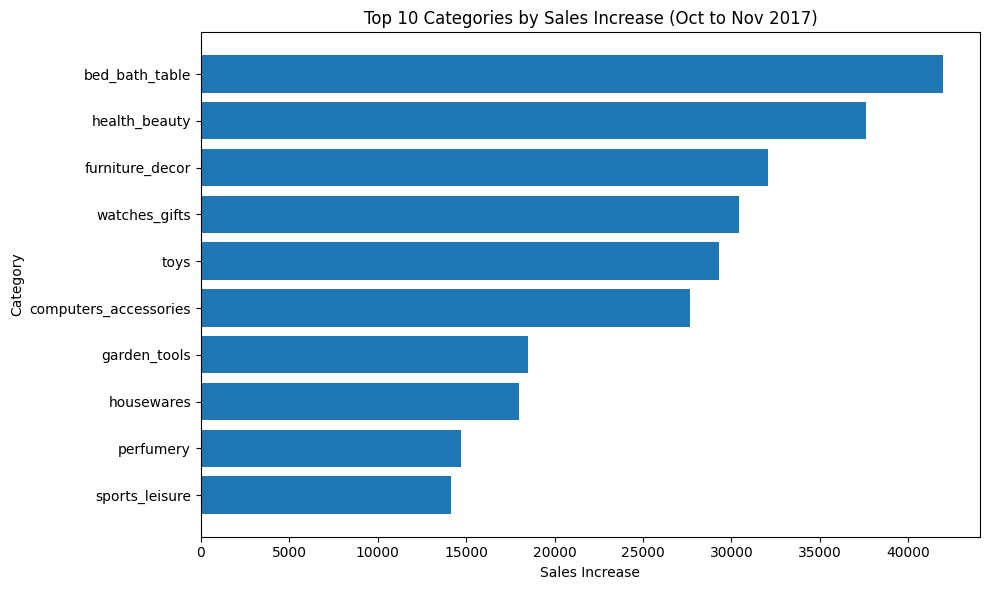

In [28]:
top10_category = oct_nov_compare.head(10).sort_values(by="sales_increase",ascending=True)
# 画横向柱状图
plt.figure(figsize=(10, 6))
plt.barh(
    top10_category["category"],top10_category["sales_increase"])
plt.xlabel("Sales Increase")
plt.ylabel("Category")
plt.title("Top 10 Categories by Sales Increase (Oct to Nov 2017)")
plt.tight_layout()
plt.show()